In [2]:

import torch
import numpy as np
from transformers import (
    RobertaForSequenceClassification,
    RobertaTokenizer,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)
from sklearn.metrics import f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from datasets import load_from_disk
import warnings
warnings.filterwarnings('ignore')


In [3]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

CUDA available: True
GPU: Tesla T4


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import zipfile


drive_zip_path = "/content/drive/MyDrive/tokenized.zip"


!cp "{drive_zip_path}" "/content/tokenized.zip"
print("✅ فایل ZIP به Colab کپی شد!")


with zipfile.ZipFile("/content/tokenized.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/tokenized")
print("✅ دیتاست در /content/tokenized/ اکسترکت شد!")


print("\n📁 محتویات پوشه tokenized:")
!ls -la /content/tokenized/


✅ فایل ZIP به Colab کپی شد!
✅ دیتاست در /content/tokenized/ اکسترکت شد!

📁 محتویات پوشه tokenized:
total 12
drwxr-xr-x 3 root root 4096 Aug 17 14:34 .
drwxr-xr-x 1 root root 4096 Aug 17 15:46 ..
drwxr-xr-x 5 root root 4096 Aug 17 14:34 tokenized


In [ ]:
!ls -laR /content/tokenized/


/content/tokenized/:
total 12
drwxr-xr-x 3 root root 4096 Aug 17 14:34 .
drwxr-xr-x 1 root root 4096 Aug 17 14:34 ..
drwxr-xr-x 5 root root 4096 Aug 17 14:34 tokenized

/content/tokenized/tokenized:
total 24
drwxr-xr-x 5 root root 4096 Aug 17 14:34 .
drwxr-xr-x 3 root root 4096 Aug 17 14:34 ..
-rw-r--r-- 1 root root   43 Aug 17 14:34 dataset_dict.json
drwxr-xr-x 2 root root 4096 Aug 17 14:34 test
drwxr-xr-x 2 root root 4096 Aug 17 14:34 train
drwxr-xr-x 2 root root 4096 Aug 17 14:34 validation

/content/tokenized/tokenized/test:
total 3584
drwxr-xr-x 2 root root    4096 Aug 17 14:34 .
drwxr-xr-x 5 root root    4096 Aug 17 14:34 ..
-rw-r--r-- 1 root root 3652608 Aug 17 14:34 data-00000-of-00001.arrow
-rw-r--r-- 1 root root     576 Aug 17 14:34 dataset_info.json
-rw-r--r-- 1 root root     262 Aug 17 14:34 state.json

/content/tokenized/tokenized/train:
total 28548
drwxr-xr-x 2 root root     4096 Aug 17 14:34 .
drwxr-xr-x 5 root root     4096 Aug 17 14:34 ..
-rw-r--r-- 1 root root 2921330

In [7]:
# ==========================================
# سلول: راه‌حل نهایی - همه روش‌ها
# ==========================================
import os
import shutil
from datasets import load_from_disk

# ۱. بررسی وجود فایل‌ها
data_path = '/content/tokenized/tokenized'
print(f"📁 Checking path: {data_path}")

if not os.path.exists(data_path):
    print("❌ Path does not exist!")
else:
    print(f"✅ Path exists")
    print(f"📁 Contents: {os.listdir(data_path)}")


        # ۴. روش سوم: بارگذاری دستی
print("\n🔄 Method 3: Manual loading with pyarrow...")

import pyarrow.ipc as ipc
import pandas as pd
from datasets import Dataset, DatasetDict

def read_arrow_file(file_path):
  with open(file_path, 'rb') as f:
    reader = ipc.open_stream(f)
    table = reader.read_all()
    return table.to_pandas()

train_df = read_arrow_file(os.path.join(data_path, 'train/data-00000-of-00001.arrow'))
val_df = read_arrow_file(os.path.join(data_path, 'validation/data-00000-of-00001.arrow'))
test_df = read_arrow_file(os.path.join(data_path, 'test/data-00000-of-00001.arrow'))

tokenized_data = DatasetDict({
                'train': Dataset.from_pandas(train_df),
                'validation': Dataset.from_pandas(val_df),
                'test': Dataset.from_pandas(test_df)
            })
print("✅ Data loaded manually with pyarrow!")

# ۵. نمایش نتیجه نهایی
if 'tokenized_data' in locals() and tokenized_data is not None:
    print("\n🎉 DATA LOADED SUCCESSFULLY!")
    print(f"   Train: {len(tokenized_data['train'])} samples")
    print(f"   Validation: {len(tokenized_data['validation'])} samples")
    print(f"   Test: {len(tokenized_data['test'])} samples")
else:
    print("\n❌ Data could not be loaded. Please check your dataset files.")

📁 Checking path: /content/tokenized/tokenized
✅ Path exists
📁 Contents: ['dataset_dict.json', 'train', 'validation', 'test']

🔄 Method 3: Manual loading with pyarrow...
✅ Data loaded manually with pyarrow!

🎉 DATA LOADED SUCCESSFULLY!
   Train: 43410 samples
   Validation: 5426 samples
   Test: 5427 samples


In [17]:
# ==========================================
# سلول: تحلیل توزیع کلاس‌ها
# ==========================================
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# استخراج همه برچسب‌ها از دیتاست آموزشی
all_labels = []
for item in tokenized_data['train']:
    label = item['label']
    if torch.is_tensor(label):
        label = label.tolist()
    all_labels.extend(label)

# شمارش تعداد هر کلاس
label_counts = Counter(all_labels)
total_samples = len(all_labels)

# نمایش آمار
print(" Class Distribution Analysis:")
print("=" * 50)
print(f"Total samples: {total_samples:,}")
print(f"Number of classes: {len(label_counts)}")
print(f"Average samples per class: {total_samples / len(label_counts):.1f}")
print(f"Min samples in a class: {min(label_counts.values())}")
print(f"Max samples in a class: {max(label_counts.values())}")

# محاسبه شاخص نامتوازنی (Imbalance Ratio)
imbalance_ratio = max(label_counts.values()) / min(label_counts.values())
print(f"Imbalance Ratio (max/min): {imbalance_ratio:.2f}")

# نمایش کلاس‌های بسیار کمیاب و بسیار پرتعداد
rare_classes = [(c, count) for c, count in label_counts.items() if count < 100]
frequent_classes = [(c, count) for c, count in label_counts.items() if count > 1000]

if rare_classes:
    print(f"\n Rare classes (< 100 samples): {len(rare_classes)} classes")
    for c, count in rare_classes[:5]:
        print(f"   Class {c}: {count} samples")
if frequent_classes:
    print(f"\n Frequent classes (> 1000 samples): {len(frequent_classes)} classes")
    for c, count in frequent_classes[:5]:
        print(f"   Class {c}: {count} samples")

 Class Distribution Analysis:
Total samples: 51,103
Number of classes: 28
Average samples per class: 1825.1
Min samples in a class: 77
Max samples in a class: 14219
Imbalance Ratio (max/min): 184.66

 Rare classes (< 100 samples): 1 classes
   Class 16: 77 samples

 Frequent classes (> 1000 samples): 18 classes
   Class 27: 14219 samples
   Class 2: 1567 samples
   Class 3: 2470 samples
   Class 26: 1060 samples
   Class 15: 2662 samples


In [18]:
# ==========================================
# سلول: معیارهای نامتوازنی
# ==========================================
from scipy.stats import entropy

# ۱. نسبت نامتوازنی (Imbalance Ratio)
ir = max(class_frequencies) / min(class_frequencies)
print(f" Imbalance Ratio: {ir:.2f}")
if ir > 10:
    print("    Highly imbalanced!")
elif ir > 5:
    print("    Moderately imbalanced")
else:
    print("    Relatively balanced")

# ۲. ضریب جینی (Gini Coefficient) - معیار نابرابری
def gini_coeff(x):
    x_sorted = np.sort(x)
    n = len(x_sorted)
    cumsum = np.cumsum(x_sorted) / np.sum(x_sorted)
    return 1 - (2 * np.sum(cumsum) / n + 1 / n)

gini = gini_coeff(class_frequencies)
print(f" Gini Coefficient: {gini:.3f}")
if gini > 0.5:
    print("    Severe imbalance")
elif gini > 0.3:
    print("    Moderate imbalance")
else:
    print("    Relatively balanced")

# ۳. محاسبه وزن‌های متوازن (برای تأیید)
from sklearn.utils.class_weight import compute_class_weight
unique_labels = np.unique(all_labels)
class_weights = compute_class_weight(class_weight='balanced', classes=unique_labels, y=all_labels)
weight_ratio = max(class_weights) / min(class_weights)
print(f" Weight Ratio (max/min): {weight_ratio:.2f}")
if weight_ratio > 5:
    print("    The model will heavily focus on rare classes!")
else:
    print("    Balanced weighting")

 Imbalance Ratio: 184.66
    Highly imbalanced!
 Gini Coefficient: 0.445
    Moderate imbalance
 Weight Ratio (max/min): 184.66
    The model will heavily focus on rare classes!


In [28]:
# ==========================================
# سلول: بارگذاری دیتاست جدید از Drive
# ==========================================
from datasets import load_from_disk

# مسیر دیتاست در Drive
drive_dataset_path = "/content/drive/MyDrive/tokenized_augmented_final"

# بارگذاری
tokenized_data = load_from_disk(drive_dataset_path)
print("✅ Augmented dataset loaded successfully from Drive!")

# نمایش اطلاعات
print(f"\n📊 Dataset Information:")
print(f"   Train samples: {len(tokenized_data['train'])}")
print(f"   Validation samples: {len(tokenized_data['validation'])}")
print(f"   Test samples: {len(tokenized_data['test'])}")

# نمایش نمونه‌ای از داده‌ها
print("\n📝 Sample from dataset:")
print(tokenized_data['train'][0])

🔄 Loading augmented dataset from Drive with pyarrow...
✅ Train loaded: 44399 samples
✅ Validation loaded: 5426 samples
✅ Test loaded: 5427 samples

✅ Augmented dataset loaded successfully with pyarrow!

📊 Dataset Information:
   Train samples: 44399
   Validation samples: 5426
   Test samples: 5427

📝 Sample from dataset:
   Input IDs length: 128
   Labels: [27]


In [41]:
# ==========================================
# سلول: محاسبه مجدد وزن کلاس‌ها
# ==========================================
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter

# استخراج برچسب‌های دیتاست جدید
all_labels_new = []
for item in tokenized_data['train']:
    label = item['label']
    if torch.is_tensor(label):
        label = label.tolist()
    all_labels_new.extend(label)

# شمارش و نمایش توزیع
new_counts = Counter(all_labels_new)
print("📊 New Class Distribution:")
print("-" * 40)
for class_id in sorted(new_counts.keys()):
    print(f"   Class {class_id}: {new_counts[class_id]} samples")

# محاسبه وزن کلاس‌ها
unique_labels = np.unique(all_labels_new)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_labels,
    y=all_labels_new
)
class_weight_dict = {int(label): weight for label, weight in zip(unique_labels, class_weights)}

print("\n✅ New class weights computed!")
print(f"   Class 16 weight: {class_weight_dict.get(16, 'N/A'):.4f}")
print(f"   Class 27 weight: {class_weight_dict.get(27, 'N/A'):.4f}")
print(f"   Weight ratio (max/min): {max(class_weights) / min(class_weights):.2f}")

📊 New Class Distribution:
----------------------------------------
   Class 0: 4178 samples
   Class 1: 2341 samples
   Class 2: 1577 samples
   Class 3: 2498 samples
   Class 4: 2961 samples
   Class 5: 1109 samples
   Class 6: 1374 samples
   Class 7: 2208 samples
   Class 8: 642 samples
   Class 9: 1288 samples
   Class 10: 2038 samples
   Class 11: 804 samples
   Class 12: 506 samples
   Class 13: 863 samples
   Class 14: 660 samples
   Class 15: 2690 samples
   Class 16: 200 samples
   Class 17: 1481 samples
   Class 18: 2094 samples
   Class 19: 437 samples
   Class 20: 1604 samples
   Class 21: 282 samples
   Class 22: 1122 samples
   Class 23: 388 samples
   Class 24: 556 samples
   Class 25: 1383 samples
   Class 26: 1066 samples
   Class 27: 14263 samples

✅ New class weights computed!
   Class 16 weight: 9.3952
   Class 27 weight: 0.1317
   Weight ratio (max/min): 71.31


In [86]:
# ==========================================
# سلول: Data Collator سفارشی برای Multi-Label
# ==========================================
class MultiLabelDataCollator:
    def __init__(self, tokenizer, num_labels=28):
        self.tokenizer = tokenizer
        self.num_labels = num_labels

    def __call__(self, features):
        labels = []
        for feature in features:
            label = feature.pop("label")
            if torch.is_tensor(label):
                label = label.tolist()
            labels.append(label)

        batch_size = len(labels)
        padded_labels = torch.zeros((batch_size, self.num_labels), dtype=torch.float32)

        for i, label_list in enumerate(labels):
            for idx in label_list:
                if idx < self.num_labels:
                    padded_labels[i, idx] = 1.0

        batch = self.tokenizer.pad(features, padding=True, return_tensors="pt")
        batch["labels"] = padded_labels

        return batch

print("✅ MultiLabelDataCollator defined!")

✅ MultiLabelDataCollator defined!


In [87]:
# ==========================================
# سلول: تابع compute_metrics برای نمایش دقیق
# ==========================================
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import numpy as np

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = (predictions > 0.5).astype(int)

    # محاسبه متریک‌ها
    f1_micro = f1_score(labels, predictions, average='micro', zero_division=0)
    f1_macro = f1_score(labels, predictions, average='macro', zero_division=0)
    f1_weighted = f1_score(labels, predictions, average='weighted', zero_division=0)
    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, average='macro', zero_division=0)
    recall = recall_score(labels, predictions, average='macro', zero_division=0)

    # متریک‌های کلاس‌های کمیاب
    rare_class_metrics = {}
    for class_id in [16, 19, 21, 23]:
        if labels.shape[1] > class_id:  # اگر کلاس وجود دارد
            class_f1 = f1_score(
                labels[:, class_id] if labels.ndim > 1 else labels,
                predictions[:, class_id] if predictions.ndim > 1 else predictions,
                average='binary',
                zero_division=0
            )
            rare_class_metrics[f'f1_class_{class_id}'] = class_f1

    return {
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'accuracy': accuracy,
        'precision_macro': precision,
        'recall_macro': recall,
        **rare_class_metrics
    }

In [88]:
# ==========================================
# سلول: CustomLoggingCallback اصلاح‌شده
# ==========================================
from transformers import TrainerCallback
import torch

class CustomLoggingCallback(TrainerCallback):
    def __init__(self, log_steps=100):
        self.log_steps = log_steps
        self.step_count = 0
        self.train_loss_sum = 0
        self.train_loss_count = 0
        self.printed_epoch = False

    def on_step_end(self, args, state, control, **kwargs):
        self.step_count += 1

        # جمع‌آوری Train Loss
        if len(state.log_history) > 0 and 'loss' in state.log_history[-1]:
            loss = state.log_history[-1]['loss']
            self.train_loss_sum += loss
            self.train_loss_count += 1

        # نمایش لاگ هر ۲۵ گام
        if self.step_count % self.log_steps == 0:
            avg_loss = self.train_loss_sum / self.train_loss_count if self.train_loss_count > 0 else 0

            # ===== دریافت نرخ یادگیری =====
            lr = None
            # روش ۱: از log_history
            for log in reversed(state.log_history):
                if 'learning_rate' in log:
                    lr = log['learning_rate']
                    break

            # روش ۲: از state.lr_scheduler (اگر وجود دارد)
            if lr is None and hasattr(state, 'lr_scheduler') and state.lr_scheduler:
                lr = state.lr_scheduler.get_last_lr()[0]

            print(f"\n📊 Step {self.step_count}:")
            print(f"   Train Loss: {avg_loss:.4f}")
            if lr is not None:
                print(f"   Learning Rate: {lr:.2e}")

            self.train_loss_sum = 0
            self.train_loss_count = 0
            self.printed_epoch = False

    def on_epoch_end(self, args, state, control, **kwargs):
        if self.printed_epoch:
            return

        print(f"\n{'='*60}")
        print(f"📊 End of Epoch {state.epoch:.1f}")
        print(f"{'='*60}")

        # نمایش نتایج Validation
        for log in state.log_history:
            if 'eval_loss' in log and log.get('epoch', 0) == state.epoch:
                print(f"\n   📈 Validation Metrics:")
                print(f"   Validation Loss: {log['eval_loss']:.4f}")
                print(f"   F1-Macro: {log.get('eval_f1_macro', 0):.4f}")
                print(f"   F1-Micro: {log.get('eval_f1_micro', 0):.4f}")
                print(f"   Accuracy: {log.get('eval_accuracy', 0):.4f}")
                break

        # نمایش متریک‌های کلاس‌های کمیاب
        rare_found = False
        for log in state.log_history:
            if 'eval_f1_class_16' in log and log.get('epoch', 0) == state.epoch:
                if not rare_found:
                    print(f"\n   🔍 Rare Classes Performance:")
                    rare_found = True
                for class_id in [16, 19, 21, 23]:
                    f1_key = f'eval_f1_class_{class_id}'
                    if f1_key in log:
                        print(f"      Class {class_id:2d}: F1 = {log[f1_key]:.4f}")

        print(f"{'='*60}\n")
        self.printed_epoch = True

In [89]:
import torch.nn as nn
import torch.nn.functional as F
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=3.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        return focal_loss.mean()

In [90]:
class FocalLossTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = torch.tensor(class_weights, dtype=torch.float32)

    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = FocalLoss(alpha=0.25, gamma=2.0)
        loss = loss_fct(logits * self.class_weights.to(logits.device), labels)

        return (loss, outputs) if return_outputs else loss

In [91]:
print("\n🔄 load base model from Google Drive...")

# مسیر مدل ذخیره شده در Drive را وارد کنید
model_path = "/content/drive/MyDrive/roberta-base-classification"  # ← این را با مسیر خودتان جایگزین کنید

model = RobertaForSequenceClassification.from_pretrained(
    model_path,  # ← به جای 'roberta-base' از مسیر Drive استفاده کنید
    num_labels=28,
    ignore_mismatched_sizes=True
)
print('✅ Model loaded successfully from Google Drive!')
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=['query', 'value','key', 'value'],
    lora_dropout=0.3,
    bias='lora_only',
    task_type=TaskType.SEQ_CLS,

)

model = get_peft_model(model, lora_config)
print("lora settings applied")
model.print_trainable_parameters()


🔄 load base model from Google Drive...
✅ Model loaded successfully from Google Drive!
lora settings applied
trainable params: 1,524,508 || all params: 126,164,024 || trainable%: 1.2084


In [92]:
# ==========================================
# سلول: تنظیمات آموزش (Hyperparameters)
# ==========================================
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/emotion_model_checkpoints",
    logging_dir="./logs",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    learning_rate=1e-4,
    weight_decay=0.15,
    warmup_steps=500,
    gradient_accumulation_steps=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=5,
    fp16=True,
    label_smoothing_factor=0.25,

    # ===== تنظیمات لاگ‌ها =====
    logging_strategy="steps",           # لاگ بر اساس تعداد گام‌ها
    report_to="none",
    logging_steps=100,
)

print("✅ Training arguments configured!")

✅ Training arguments configured!


In [93]:

class_weights_list = [class_weight_dict.get(i, 1.0) for i in range(28)]

# ==========================================
# سلول: ساخت Trainer نهایی
# ==========================================
from transformers import EarlyStoppingCallback

# تبدیل class_weight_dict به لیست
class_weights_list = [class_weight_dict.get(i, 1.0) for i in range(28)]

# ایجاد Trainer با Callback جدید
trainer = FocalLossTrainer(
    class_weights=class_weights_list,
    model=model,
    args=training_args,
    train_dataset=tokenized_data['train'],
    eval_dataset=tokenized_data['validation'],
    compute_metrics=compute_metrics,
    data_collator=MultiLabelDataCollator(tokenizer, num_labels=28),
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2),
        CustomLoggingCallback(log_steps=100)  # ← لاگ هر ۲۵ گام + پایان هر Epoch
    ]
)

print("✅ Trainer with custom logging is ready!")


✅ Trainer with custom logging is ready!


In [94]:
# ==========================================
# سلول: شروع آموزش
# ==========================================
print("🚀 Starting training...")
print(f"   Train samples: {len(tokenized_data['train'])}")
print(f"   Validation samples: {len(tokenized_data['validation'])}")
print(f"   Test samples: {len(tokenized_data['test'])}")
print(f"   Total epochs: {training_args.num_train_epochs}")
print("=" * 50)

# اجرای آموزش
trainer.train()

print("✅ Training completed successfully!")

🚀 Starting training...
   Train samples: 44399
   Validation samples: 5426
   Test samples: 5427
   Total epochs: 5


Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,F1 Weighted,Accuracy,Precision Macro,Recall Macro,F1 Class 16,F1 Class 19,F1 Class 21,F1 Class 23
0,0.007100,0.006386,0.340183,0.177169,0.284848,0.211205,0.428800,0.136238,0.000000,0.000000,0.000000,0.000000
2,0.006400,0.005842,0.452435,0.231716,0.394284,0.314781,0.677682,0.175675,0.000000,0.000000,0.000000,0.000000
4,0.005900,0.005711,0.460919,0.220762,0.396047,0.323258,0.650015,0.170753,0.000000,0.000000,0.000000,0.000000



📊 Step 100:
   Train Loss: 0.0000

📊 Step 200:
   Train Loss: 0.0408
   Learning Rate: 2.00e-05

📊 Step 300:
   Train Loss: 0.0159
   Learning Rate: 4.00e-05

📊 Step 400:
   Train Loss: 0.0114
   Learning Rate: 6.00e-05

📊 Step 500:
   Train Loss: 0.0110
   Learning Rate: 8.00e-05

📊 Step 600:
   Train Loss: 0.0100
   Learning Rate: 1.00e-04

📊 Step 700:
   Train Loss: 0.0090
   Learning Rate: 9.84e-05

📊 Step 800:
   Train Loss: 0.0083
   Learning Rate: 9.69e-05

📊 Step 900:
   Train Loss: 0.0080
   Learning Rate: 9.53e-05

📊 Step 1000:
   Train Loss: 0.0077
   Learning Rate: 9.38e-05

📊 Step 1100:
   Train Loss: 0.0077
   Learning Rate: 9.22e-05

📊 Step 1200:
   Train Loss: 0.0071
   Learning Rate: 9.07e-05

📊 Step 1300:
   Train Loss: 0.0072
   Learning Rate: 8.91e-05

📊 End of Epoch 1.0


📊 Step 1400:
   Train Loss: 0.0071
   Learning Rate: 8.76e-05

📊 Step 1500:
   Train Loss: 0.0069
   Learning Rate: 8.60e-05

📊 Step 1600:
   Train Loss: 0.0067
   Learning Rate: 8.45e-05

📊 Step

In [95]:
# ==========================================
# سلول: ذخیره مدل نهایی
# ==========================================
import shutil
import os
import json

print("💾 Saving final model...")

# ۱. ذخیره در محیط محلی Colab
model.save_pretrained("./emotion_model_lora_final")
tokenizer.save_pretrained("./emotion_model_lora_final")
print("✅ Model saved locally at ./emotion_model_lora_final")

# ۲. ذخیره در Google Drive
drive_model_path = "/content/drive/MyDrive/emotion_model_lora_final"

# اگر پوشه قبلاً وجود داشت، حذفش کن
if os.path.exists(drive_model_path):
    shutil.rmtree(drive_model_path)

# کپی پوشه به Drive
shutil.copytree("./emotion_model_lora_final", drive_model_path)
print(f"✅ Model copied to Drive: {drive_model_path}")

# ۳. نمایش محتویات
print("\n📁 Model contents:")
!ls -la {drive_model_path}/

💾 Saving final model...
✅ Model saved locally at ./emotion_model_lora_final
✅ Model copied to Drive: /content/drive/MyDrive/emotion_model_lora_final

📁 Model contents:
total 7289
-rw------- 1 root root     718 Aug 17 18:58 adapter_config.json
-rw------- 1 root root 5998232 Aug 17 18:58 adapter_model.safetensors
-rw------- 1 root root  456318 Aug 17 18:58 merges.txt
-rw------- 1 root root    5124 Aug 17 18:58 README.md
-rw------- 1 root root     958 Aug 17 18:58 special_tokens_map.json
-rw------- 1 root root    1191 Aug 17 18:58 tokenizer_config.json
-rw------- 1 root root  999355 Aug 17 18:58 vocab.json


In [97]:
# ==========================================
# سلول: ارزیابی نهایی روی تست (اصلاح‌شده)
# ==========================================
print("📊 Evaluating on test set...")

test_results = trainer.evaluate(tokenized_data['test'])

print("\n" + "=" * 60)
print("📊 FINAL TEST RESULTS")
print("=" * 60)

print(f"\n🎯 Overall Metrics:")
print(f"   F1-Macro:  {test_results['eval_f1_macro']:.4f}")
print(f"   F1-Micro:  {test_results['eval_f1_micro']:.4f}")
print(f"   Accuracy:  {test_results['eval_accuracy']:.4f}")
print(f"   Loss:      {test_results['eval_loss']:.4f}")

# ===== نمایش متریک‌های کلاس‌های کمیاب (فقط در صورت وجود) =====
print(f"\n🔍 Rare Classes Performance:")

rare_classes_found = False
for class_id in [16, 19, 21, 23]:
    f1_key = f'eval_f1_class_{class_id}'
    recall_key = f'eval_recall_class_{class_id}'
    precision_key = f'eval_precision_class_{class_id}'

    # بررسی وجود کلیدها قبل از دسترسی
    if f1_key in test_results:
        rare_classes_found = True
        print(f"\n   Class {class_id}:")
        print(f"      F1:        {test_results[f1_key]:.4f}")

        # بررسی وجود Recall
        if recall_key in test_results:
            print(f"      Recall:    {test_results[recall_key]:.4f}")
        else:
            print(f"      Recall:    N/A")

        # بررسی وجود Precision
        if precision_key in test_results:
            print(f"      Precision: {test_results[precision_key]:.4f}")
        else:
            print(f"      Precision: N/A")

if not rare_classes_found:
    print("   No rare class metrics available.")
    print("   (Make sure compute_metrics includes f1_class_* metrics)")

📊 Evaluating on test set...



📊 FINAL TEST RESULTS

🎯 Overall Metrics:
   F1-Macro:  0.2360
   F1-Micro:  0.4596
   Accuracy:  0.3188
   Loss:      0.0058

🔍 Rare Classes Performance:

   Class 16:
      F1:        0.0000
      Recall:    N/A
      Precision: N/A

   Class 19:
      F1:        0.0000
      Recall:    N/A
      Precision: N/A

   Class 21:
      F1:        0.0000
      Recall:    N/A
      Precision: N/A

   Class 23:
      F1:        0.0000
      Recall:    N/A
      Precision: N/A


In [98]:
# ==========================================
# سلول: ذخیره نتایج به صورت JSON
# ==========================================
import json

# ۱. ذخیره در محیط محلی
with open("./emotion_model_lora_final/test_results.json", 'w') as f:
    json.dump(test_results, f, indent=4)
print("✅ Results saved locally")

# ۲. کپی به Drive
shutil.copy2(
    "./emotion_model_lora_final/test_results.json",
    "/content/drive/MyDrive/emotion_model_lora_final/test_results.json"
)
print("✅ Results copied to Drive")

# ۳. نمایش خلاصه نتایج
print("\n📊 Results saved to:")
print(f"   {drive_model_path}/test_results.json")

✅ Results saved locally
✅ Results copied to Drive

📊 Results saved to:
   /content/drive/MyDrive/emotion_model_lora_final/test_results.json


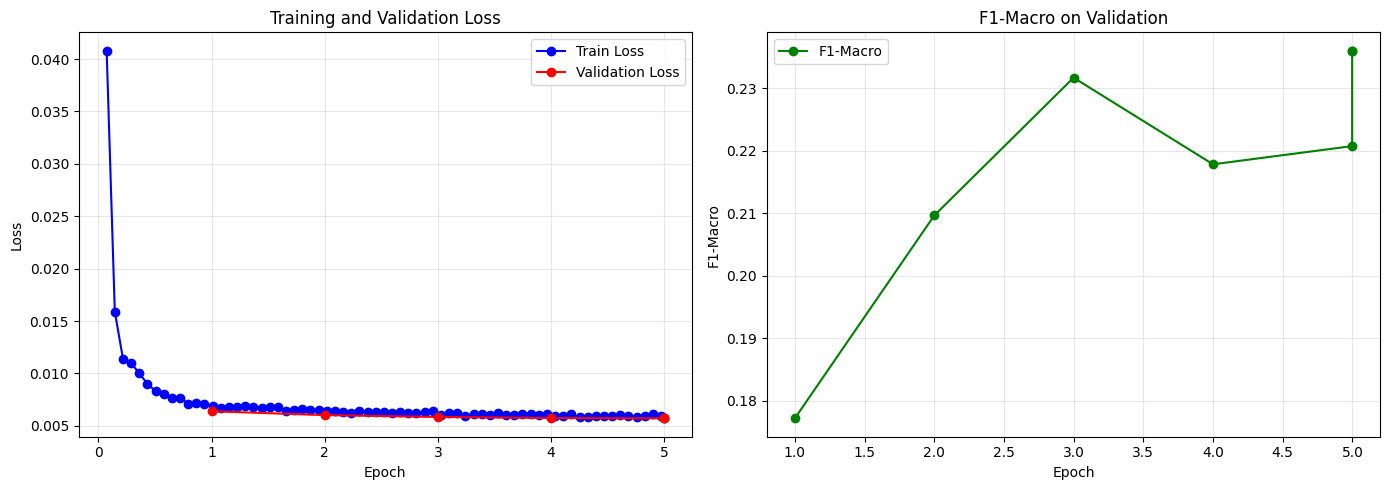

✅ Training curves saved to Drive!


In [99]:
# ==========================================
# سلول: رسم نمودارهای عملکرد
# ==========================================
import matplotlib.pyplot as plt

# استخراج تاریخچه آموزش از trainer
training_history = trainer.state.log_history

# استخراج Loss و F1 در هر دوره
epochs = []
train_losses = []
val_losses = []
f1_scores = []

for log in training_history:
    if 'epoch' in log:
        epoch = log['epoch']
        if 'loss' in log:
            train_losses.append((epoch, log['loss']))
        if 'eval_loss' in log:
            val_losses.append((epoch, log['eval_loss']))
        if 'eval_f1_macro' in log:
            f1_scores.append((epoch, log['eval_f1_macro']))

# رسم نمودارها
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# نمودار Loss
if train_losses and val_losses:
    train_epochs, train_vals = zip(*train_losses)
    val_epochs, val_vals = zip(*val_losses)

    axes[0].plot(train_epochs, train_vals, 'b-o', label='Train Loss')
    axes[0].plot(val_epochs, val_vals, 'r-o', label='Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# نمودار F1
if f1_scores:
    f1_epochs, f1_vals = zip(*f1_scores)
    axes[1].plot(f1_epochs, f1_vals, 'g-o', label='F1-Macro')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('F1-Macro')
    axes[1].set_title('F1-Macro on Validation')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/emotion_model_lora_final/training_curves.png", dpi=150)
plt.show()

print("✅ Training curves saved to Drive!")

In [100]:
# ==========================================
# سلول: گزارش نهایی
# ==========================================
print("=" * 60)
print("🎉 TRAINING COMPLETED SUCCESSFULLY!")
print("=" * 60)

print("\n📊 Model Information:")
print(f"   Model type: RoBERTa-base with LoRA")
print(f"   LoRA rank: 8")
print(f"   Trainable parameters: {model.num_parameters(only_trainable=True):,}")
print(f"   Total parameters: {model.num_parameters():,}")

print("\n📁 Saved Files:")
print(f"   Model: /content/drive/MyDrive/emotion_model_lora_final/")
print(f"   Checkpoints: /content/drive/MyDrive/emotion_model_checkpoints/")
print(f"   Results: /content/drive/MyDrive/emotion_model_lora_final/test_results.json")
print(f"   Curves: /content/drive/MyDrive/emotion_model_lora_final/training_curves.png")

print("\n📊 Final Test Performance:")
print(f"   F1-Macro:  {test_results['eval_f1_macro']:.4f}")
print(f"   F1-Micro:  {test_results['eval_f1_micro']:.4f}")
print(f"   Accuracy:  {test_results['eval_accuracy']:.4f}")

# نمایش کلاس‌های کمیاب
print("\n🔍 Rare Classes Performance:")
for class_id in [16, 19, 21, 23]:
    f1_key = f'eval_f1_class_{class_id}'
    if f1_key in test_results:
        print(f"   Class {class_id}: {test_results[f1_key]:.4f}")

print("\n✅ All done! Your model is ready for use.")

🎉 TRAINING COMPLETED SUCCESSFULLY!

📊 Model Information:
   Model type: RoBERTa-base with LoRA
   LoRA rank: 8
   Trainable parameters: 1,524,508
   Total parameters: 126,164,024

📁 Saved Files:
   Model: /content/drive/MyDrive/emotion_model_lora_final/
   Checkpoints: /content/drive/MyDrive/emotion_model_checkpoints/
   Results: /content/drive/MyDrive/emotion_model_lora_final/test_results.json
   Curves: /content/drive/MyDrive/emotion_model_lora_final/training_curves.png

📊 Final Test Performance:
   F1-Macro:  0.2360
   F1-Micro:  0.4596
   Accuracy:  0.3188

🔍 Rare Classes Performance:
   Class 16: 0.0000
   Class 19: 0.0000
   Class 21: 0.0000
   Class 23: 0.0000

✅ All done! Your model is ready for use.


In [102]:
# ==========================================
# سلول: تابع پیش‌بینی احساسات
# ==========================================
import torch
import numpy as np

# لیست نام احساسات (بر اساس کلاس‌های GoEmotions)
EMOTION_NAMES = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval',
    'caring', 'confusion', 'curiosity', 'desire', 'disappointment',
    'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear',
    'gratitude', 'grief', 'joy', 'love', 'nervousness',
    'optimism', 'pride', 'realization', 'relief', 'remorse',
    'sadness', 'surprise', 'neutral'
]

def predict_emotion(text, model, tokenizer, threshold=0.5, top_k=5):
    """
    پیش‌بینی احساسات یک متن

    Args:
        text (str): متن ورودی
        model: مدل آموزش‌دیده
        tokenizer: توکنایزر
        threshold (float): آستانه تشخیص (پیش‌فرض 0.5)
        top_k (int): تعداد احساسات برتر برای نمایش

    Returns:
        dict: شامل احساسات پیش‌بینی‌شده و احتمالات
    """
    # ۱. توکنایز کردن متن
    inputs = tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )

    # ۲. انتقال به GPU اگر موجود باشد
    if torch.cuda.is_available():
        inputs = {k: v.cuda() for k, v in inputs.items()}
        model = model.cuda()

    # ۳. پیش‌بینی
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probabilities = torch.sigmoid(logits).cpu().numpy()[0]

    # ۴. استخراج احساسات با احتمال بالاتر از آستانه
    predicted_indices = np.where(probabilities > threshold)[0]
    predicted_emotions = []

    for idx in predicted_indices:
        predicted_emotions.append({
            'emotion': EMOTION_NAMES[idx],
            'class_id': idx,
            'probability': probabilities[idx]
        })

    # ۵. مرتب‌سازی بر اساس احتمال (بالا به پایین)
    predicted_emotions.sort(key=lambda x: x['probability'], reverse=True)

    # ۶. نمایش نتایج
    print(f"\n📝 Text: {text}")
    print("-" * 60)

    if predicted_emotions:
        print(f"🔍 Detected emotions ({len(predicted_emotions)}):")
        for i, emotion in enumerate(predicted_emotions[:top_k]):
            bar = '█' * int(emotion['probability'] * 50)
            print(f"   {i+1}. {emotion['emotion']:15s} ({emotion['class_id']:2d}): {emotion['probability']:.4f} {bar}")

        if len(predicted_emotions) > top_k:
            print(f"   ... and {len(predicted_emotions) - top_k} more emotions")
    else:
        print("   No emotion detected (all probabilities below threshold)")

    return predicted_emotions



# تعریف چند مثال برای تست
test_examples = [
    "I absolutely love this movie! It's the best film I've ever seen.",
    "I'm so sad and heartbroken. I can't stop crying.",
    "This is the most exciting news I've heard all year!",
    "I feel so anxious about my exam tomorrow.",
    "Thank you so much for your help! I really appreciate it.",
    "I'm so angry right now! I can't believe what just happened.",
    "The weather is nice today. Nothing special.",
    "I'm so proud of you! You did an amazing job.",
    "I'm really confused about what to do next.",
    "This is absolutely disgusting! I can't stand it.",
]

print("=" * 60)
print("🧪 TESTING MODEL WITH CUSTOM EXAMPLES")
print("=" * 60)

for text in test_examples:
    predict_emotion(text, model, tokenizer, threshold=0.5, top_k=5)


🧪 TESTING MODEL WITH CUSTOM EXAMPLES

📝 Text: I absolutely love this movie! It's the best film I've ever seen.
------------------------------------------------------------
🔍 Detected emotions (2):
   1. love            (18): 0.6188 ██████████████████████████████
   2. admiration      ( 0): 0.5654 ████████████████████████████

📝 Text: I'm so sad and heartbroken. I can't stop crying.
------------------------------------------------------------
🔍 Detected emotions (1):
   1. sadness         (25): 0.6969 ██████████████████████████████████

📝 Text: This is the most exciting news I've heard all year!
------------------------------------------------------------
🔍 Detected emotions (1):
   1. excitement      (13): 0.6192 ██████████████████████████████

📝 Text: I feel so anxious about my exam tomorrow.
------------------------------------------------------------
🔍 Detected emotions (1):
   1. nervousness     (19): 0.5726 ████████████████████████████

📝 Text: Thank you so much for your help! I r

In [103]:
rare_examples = [
    # Grief (کلاس ۱۶)
    "I can't believe she's gone. I miss her so much every day.",
    "My heart is broken into a million pieces. I'll never be the same.",

    # Nervousness (کلاس ۱۹)
    "I'm so nervous about my job interview tomorrow.",
    "My hands are shaking and I can't stop worrying.",

    # Pride (کلاس ۲۱)
    "I'm so proud of my daughter for graduating with honors.",
    "I've worked so hard and finally achieved my dream!",

    # Relief (کلاس ۲۳)
    "Thank goodness that's over! I feel so relieved now.",
    "I'm so glad I don't have to worry about that anymore.",
]

for text in rare_examples:
    predict_emotion(text, model, tokenizer, threshold=0.5, top_k=5)



📝 Text: I can't believe she's gone. I miss her so much every day.
------------------------------------------------------------
🔍 Detected emotions (1):
   1. sadness         (25): 0.6068 ██████████████████████████████

📝 Text: My heart is broken into a million pieces. I'll never be the same.
------------------------------------------------------------
🔍 Detected emotions (1):
   1. sadness         (25): 0.6251 ███████████████████████████████

📝 Text: I'm so nervous about my job interview tomorrow.
------------------------------------------------------------
🔍 Detected emotions (1):
   1. nervousness     (19): 0.5550 ███████████████████████████

📝 Text: My hands are shaking and I can't stop worrying.
------------------------------------------------------------
🔍 Detected emotions (1):
   1. nervousness     (19): 0.5519 ███████████████████████████

📝 Text: I'm so proud of my daughter for graduating with honors.
------------------------------------------------------------
🔍 Detected emot